Smart City UrbanHub – Partie 4
Analyse croisée des données

Cette partie vise à croiser les données issues des trois flux du projet :

Flux Batch (Météo – NOAA)
Flux Streaming (Mobilité douce – CityBikes)
Flux IoT (Pollution – OpenAQ)

Objectif : construire un dataset analytique commun permettant de répondre aux questions métier transverses et préparer les futurs tableaux de bord.

4.1 — Conception des indicateurs croisés
Questions métier officielles
Question 1

Existe-t-il une relation entre conditions météorologiques et pollution ?

Question 2

Les conditions météo influencent-elles l'utilisation des vélos urbains ?

Question 3

Peut-on identifier des conditions météorologiques favorables à la mobilité douce ?

Question 4

Existe-t-il des périodes où mobilité, pollution et météo interagissent fortement ?

Indicateur 1 — Corrélation météo → pollution
Objectif

Mesurer l'influence des conditions météorologiques sur les niveaux de pollution.

Hypothèses
Les précipitations réduisent les particules par effet de lessivage.
Le vent favorise la dispersion des polluants.
L'ozone (O3) augmente lors des périodes chaudes.
Variables utilisées

Météo :

precipitation_mm
wind_speed_kmh
temperature_avg_c

Pollution :

pm25
pm10
no2
o3
pollution_index
Visualisations prévues
Scatter pluie vs pollution_index
Scatter vent vs pollution_index
Scatter température vs ozone

Indicateur 2 — Corrélation météo → usage vélos
Objectif

Mesurer l'influence des conditions météorologiques sur l'utilisation de la mobilité douce.

Hypothèses
Une température modérée favorise l'usage.
La pluie réduit les déplacements.
Le vent fort réduit les déplacements.
Variables utilisées
temperature_avg_c
precipitation_mm
wind_speed_kmh
nb_trajets_estimes
Visualisations prévues
Scatter pluie vs trajets
Scatter température vs trajets

Indicateur 3 — score_meteo_favorable_velo
Objectif

Créer un score compris entre 0 et 100 permettant de qualifier une journée comme favorable à la mobilité douce.

Principes

Le score augmente lorsque :

température proche de 20°C
pluie faible
vent faible
Formule conceptuelle

Score =

50 % température
30 % pluie
20 % vent

Valeur finale bornée entre 0 et 100.

Indicateur 4 — atypie_score
Objectif

Détecter les journées où plusieurs phénomènes anormaux apparaissent simultanément.

Variables retenues
precipitation_mm
pollution_index
nb_trajets_estimes
Méthode

Calcul des z-scores par ville :

z = (valeur - moyenne) / écart-type

Puis :

atypie_score =
|z_precipitation|
+
|z_pollution|
+
|z_mobilite|

Les journées ayant les scores les plus élevés seront considérées comme atypiques.

| Table Gold     | Variables requises                                                                                         |
| -------------- | ---------------------------------------------------------------------------------------------------------- |
| gold_weather   | date, city, temperature_avg_c, precipitation_mm, wind_speed_kmh, visibility_km                             |
| gold_bikes     | date, city, avg_bikes_available, avg_free_slots, occupancy_rate, nb_trajets_estimes, nb_stations_critiques |
| gold_pollution | date, city, pm25, pm10, no2, o3, co, pollution_index                                                       |


Granularité commune retenue
Niveau d'analyse

1 ligne = 1 ville + 1 jour

Granularité :

Quotidienne
Par ville

Cette granularité suppose une agrégation préalable :

données horaires NOAA → journalier
données minute CityBikes → journalier
données capteurs OpenAQ → journalier

Cette hypothèse devra être confirmée avec les responsables des parties 1, 2 et 3.

| Colonne                    | Type   | Description        |
| -------------------------- | ------ | ------------------ |
| date                       | date   | Jour d'observation |
| city                       | string | Ville              |
| temperature_avg_c          | float  |                    |
| precipitation_mm           | float  |                    |
| wind_speed_kmh             | float  |                    |
| visibility_km              | float  |                    |
| weather_condition          | string |                    |
| avg_bikes_available        | float  |                    |
| avg_free_slots             | float  |                    |
| occupancy_rate             | float  |                    |
| nb_trajets_estimes         | int    |                    |
| nb_stations_critiques      | int    |                    |
| pm25                       | float  |                    |
| pm10                       | float  |                    |
| no2                        | float  |                    |
| o3                         | float  |                    |
| co                         | float  |                    |
| pollution_index            | float  |                    |
| score_meteo_favorable_velo | float  |                    |
| atypie_score               | float  |                    |


In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path

np.random.seed(42)

4.2 — Construction du dataset

In [16]:
DATA_SOURCE = "mock"

if DATA_SOURCE == "mock":
    print("Mode données factices")

elif DATA_SOURCE == "minio":

    # FUTUR CODE MINIO
    #
    # from minio import Minio
    #
    # client = Minio(...)
    # obj = client.get_object(...)
    # pd.read_parquet(...)
    #
    raise NotImplementedError("Connexion MinIO non implémentée")

elif DATA_SOURCE == "postgres":

    # FUTUR CODE POSTGRESQL
    #
    # from sqlalchemy import create_engine
    #
    # engine = create_engine(...)
    # pd.read_sql(...)
    #
    raise NotImplementedError("Connexion PostgreSQL non implémentée")

Mode données factices


In [17]:
cities = [
    "Paris",
    "Lyon",
    "Marseille",
    "Lille"
]

dates = pd.date_range(
    end=pd.Timestamp.today().normalize(),
    periods=120
)

Génération des données météo Gold

In [18]:
weather_rows = []

for city in cities:

    temp_base = {
        "Paris":18,
        "Lyon":20,
        "Marseille":23,
        "Lille":16
    }[city]

    for d in dates:

        temp = np.random.normal(temp_base,5)

        rain = max(
            0,
            np.random.gamma(1.5,2)
        )

        wind = np.random.normal(15,5)

        visibility = np.random.normal(12,2)

        weather_rows.append([
            d.date(),
            city,
            temp,
            rain,
            wind,
            visibility
        ])

gold_weather = pd.DataFrame(
    weather_rows,
    columns=[
        "date",
        "city",
        "temperature_avg_c",
        "precipitation_mm",
        "wind_speed_kmh",
        "visibility_km"
    ]
)

In [19]:
for city in cities:

    idx = gold_weather[
        gold_weather.city == city
    ].sample(
        3,
        random_state=42
    ).index

    gold_weather.loc[idx,"precipitation_mm"] += 35
    gold_weather.loc[idx,"wind_speed_kmh"] += 25
    gold_weather.loc[idx,"visibility_km"] = 3

In [20]:
conditions = []

for _, row in gold_weather.iterrows():

    if row["visibility_km"] < 5:
        conditions.append("fog")

    elif row["precipitation_mm"] > 25:
        conditions.append("storm")

    elif row["precipitation_mm"] > 5:
        conditions.append("rain")

    elif row["temperature_avg_c"] > 22:
        conditions.append("clear")

    else:
        conditions.append("cloudy")

gold_weather["weather_condition"] = conditions

Génération des données vélos Gold

In [21]:
bike_rows = []

for _, row in gold_weather.iterrows():

    temp = row.temperature_avg_c
    rain = row.precipitation_mm
    wind = row.wind_speed_kmh

    temp_score = max(
        0,
        1 - abs(temp-20)/20
    )

    rain_penalty = np.exp(-rain/8)

    wind_penalty = np.exp(-wind/25)

    demand_factor = (
        temp_score
        * rain_penalty
        * wind_penalty
    )

    trips = int(
        1500
        + demand_factor*4500
        + np.random.normal(0,250)
    )

    occupancy = np.clip(
        np.random.normal(0.55,0.15),
        0.05,
        0.95
    )

    bike_rows.append([
        row.date,
        row.city,
        np.random.randint(300,700),
        np.random.randint(300,700),
        occupancy,
        trips,
        np.random.randint(2,15)
    ])

gold_bikes = pd.DataFrame(
    bike_rows,
    columns=[
        "date",
        "city",
        "avg_bikes_available",
        "avg_free_slots",
        "occupancy_rate",
        "nb_trajets_estimes",
        "nb_stations_critiques"
    ]
)

Génération des données pollution Gold

In [22]:
pollution_rows = []

for _, row in gold_weather.iterrows():

    rain = row.precipitation_mm
    wind = row.wind_speed_kmh
    temp = row.temperature_avg_c

    accumulation = (
        1/(1+rain/10)
    ) * (
        1/(1+wind/20)
    )

    pm25 = 10 + accumulation*30 + np.random.normal(0,2)
    pm10 = 15 + accumulation*35 + np.random.normal(0,2)
    no2 = 20 + accumulation*25 + np.random.normal(0,2)

    o3 = 30 + temp*1.2 + np.random.normal(0,2)

    co = 0.3 + accumulation*1.5

    pollution_rows.append([
        row.date,
        row.city,
        pm25,
        pm10,
        no2,
        o3,
        co
    ])

gold_pollution = pd.DataFrame(
    pollution_rows,
    columns=[
        "date",
        "city",
        "pm25",
        "pm10",
        "no2",
        "o3",
        "co"
    ]
)

In [23]:
pollution_cols = [
    "pm25",
    "pm10",
    "no2",
    "o3",
    "co"
]

gold_pollution["pollution_index"] = (
    gold_pollution[pollution_cols]
    .apply(
        lambda x:(x-x.min())/(x.max()-x.min())
    )
    .mean(axis=1)
    *100
)

Construction du dataset analytique

In [24]:
df = (
    gold_weather
    .merge(
        gold_bikes,
        on=["date","city"],
        how="inner"
    )
    .merge(
        gold_pollution,
        on=["date","city"],
        how="inner"
    )
)

In [25]:
df["date"] = pd.to_datetime(df["date"]).dt.date
df["city"] = df["city"].str.title()

Contrôles qualité

In [26]:
duplicates = df.duplicated(
    subset=["date","city"]
).sum()

print("Doublons :", duplicates)

Doublons : 0


In [27]:
missing_rate = (
    df.isna()
      .mean()
      .sort_values(
          ascending=False
      )
)

display(missing_rate)

date                     0.0
city                     0.0
co                       0.0
o3                       0.0
no2                      0.0
pm10                     0.0
pm25                     0.0
nb_stations_critiques    0.0
nb_trajets_estimes       0.0
occupancy_rate           0.0
avg_free_slots           0.0
avg_bikes_available      0.0
weather_condition        0.0
visibility_km            0.0
wind_speed_kmh           0.0
precipitation_mm         0.0
temperature_avg_c        0.0
pollution_index          0.0
dtype: float64

Calcul des indicateurs croisés

In [28]:
temp_score = (
    1 -
    abs(df["temperature_avg_c"]-20)/20
)

rain_score = np.exp(
    -df["precipitation_mm"]/10
)

wind_score = np.exp(
    -df["wind_speed_kmh"]/25
)

df["score_meteo_favorable_velo"] = (
    (
        temp_score*0.5
        + rain_score*0.3
        + wind_score*0.2
    ) * 100
).clip(0,100)

In [29]:
for col in [
    "precipitation_mm",
    "pollution_index",
    "nb_trajets_estimes"
]:

    df[f"z_{col}"] = (
        df.groupby("city")[col]
          .transform(
              lambda x:
              (x-x.mean())/x.std()
          )
    )

df["atypie_score"] = (
    df["z_precipitation_mm"].abs()
    + df["z_pollution_index"].abs()
    + df["z_nb_trajets_estimes"].abs()
)

In [30]:
df.to_csv(
    "urbanhub_analytics.csv",
    index=False
)

# FUTUR :
#
# df.to_sql(
#     "urbanhub_analytics",
#     engine,
#     if_exists="replace",
#     index=False
# )

4.3 — Dashboards et visualisations

In [31]:
def plot_pollution(ax, data):

    colors = {
        "Paris":"tab:blue",
        "Lyon":"tab:orange",
        "Marseille":"tab:green",
        "Lille":"tab:red"
    }

    for city, subset in data.groupby("city"):

        ax.scatter(
            subset["wind_speed_kmh"],
            subset["pollution_index"],
            alpha=0.6,
            label=city,
            color=colors[city]
        )

    x = data["wind_speed_kmh"]
    y = data["pollution_index"]

    coef = np.polyfit(x,y,1)

    ax.plot(
        x,
        coef[0]*x+coef[1],
        linewidth=2
    )

    ax.set_title(
        "Vent vs Pollution"
    )

In [32]:
def plot_bikes(ax, data):

    for city, subset in data.groupby("city"):

        ax.scatter(
            subset["precipitation_mm"],
            subset["nb_trajets_estimes"],
            alpha=0.6,
            label=city
        )

    x = data["precipitation_mm"]
    y = data["nb_trajets_estimes"]

    coef = np.polyfit(x,y,1)

    ax.plot(
        x,
        coef[0]*x+coef[1]
    )

    ax.set_title(
        "Pluie vs Usage vélos"
    )

In [33]:
def plot_meteo_favorable_vs_bikes(ax,data):

    ax.scatter(
        data["score_meteo_favorable_velo"],
        data["nb_trajets_estimes"],
        alpha=0.5
    )

    ax.set_title(
        "Score météo vs trajets"
    )

In [34]:
def plot_atypie(ax,data,city):

    subset = (
        data[data.city==city]
        .copy()
    )

    cols = [
        "precipitation_mm",
        "pollution_index",
        "nb_trajets_estimes"
    ]

    norm = (
        subset[cols]
        - subset[cols].min()
    ) / (
        subset[cols].max()
        - subset[cols].min()
    )

    ax.plot(
        subset["date"],
        norm["precipitation_mm"],
        label="Pluie"
    )

    ax.plot(
        subset["date"],
        norm["pollution_index"],
        label="Pollution"
    )

    ax.plot(
        subset["date"],
        norm["nb_trajets_estimes"],
        label="Mobilité"
    )

    top = subset.nlargest(
        5,
        "atypie_score"
    )

    ax.scatter(
        top["date"],
        [1.02]*len(top),
        color="red"
    )

    ax.legend(
        bbox_to_anchor=(1.05,1)
    )

    ax.set_title(
        f"Atypies - {city}"
    )

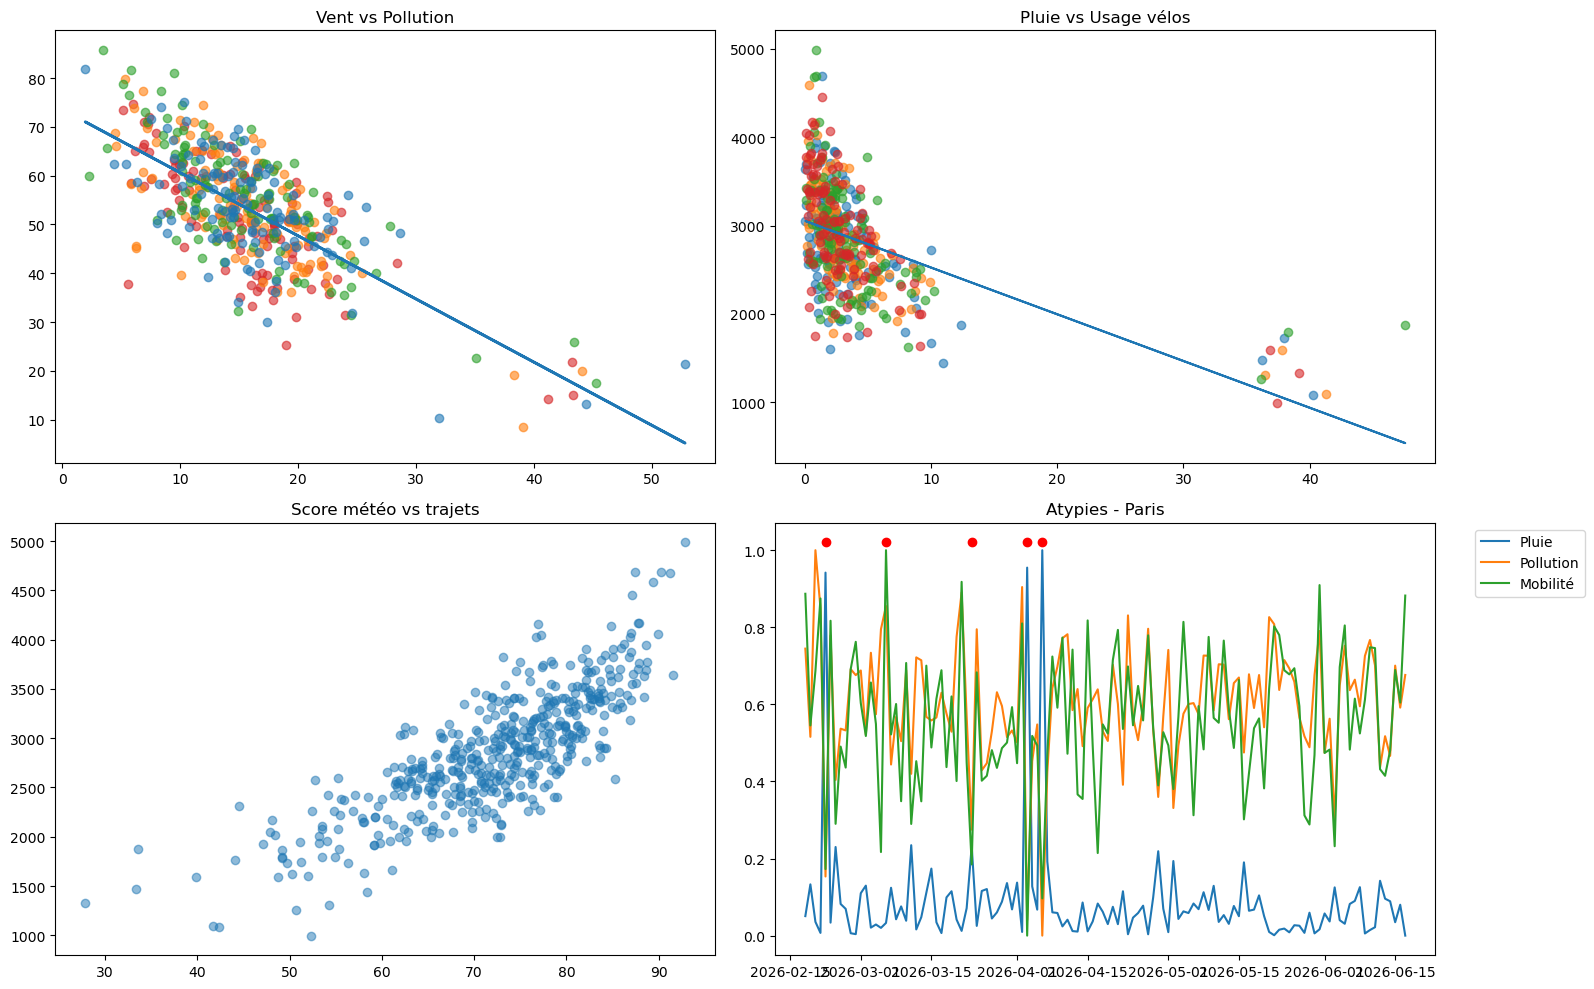

In [35]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

plot_pollution(ax[0,0],df)
plot_bikes(ax[0,1],df)
plot_meteo_favorable_vs_bikes(ax[1,0],df)
plot_atypie(ax[1,1],df,"Paris")

plt.tight_layout()

plt.savefig(
    "dashboard_urbanhub.png",
    dpi=300
)

plt.show()

Bonus : graphique interactif Plotly

In [36]:
city = "Paris"

subset = df[
    df.city == city
].copy()

fig = px.line(
    subset,
    x="date",
    y=[
        "precipitation_mm",
        "pollution_index",
        "nb_trajets_estimes"
    ],
    title=f"UrbanHub - {city}"
)

fig.update_xaxes(
    rangeslider_visible=True
)

fig.write_html(
    "urbanhub_timeseries_interactive.html"
)

fig.show()

Étapes pour brancher les vraies données Gold

Lorsque les parties 1, 2 et 3 seront livrées :

Remplacer DATA_SOURCE = "mock" par :
"minio" ou
"postgres"
Décommenter les connecteurs :
MinIO (boto3 / MinIO SDK)
PostgreSQL (SQLAlchemy)
Vérifier la correspondance exacte des noms de colonnes des tables Gold réelles.
Confirmer avec les équipes :
la granularité des données,
les règles d'agrégation quotidienne,
les villes réellement disponibles.
Rejouer intégralement le notebook.
Vérifier les contrôles qualité :
doublons,
valeurs manquantes,
cohérence des jointures.
Régénérer :
urbanhub_analytics.csv
dashboard_urbanhub.png
urbanhub_timeseries_interactive.html

Le code métier (indicateurs, visualisations, dashboards) ne nécessitera alors aucune modification structurelle.